Using Device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.96MB/s]


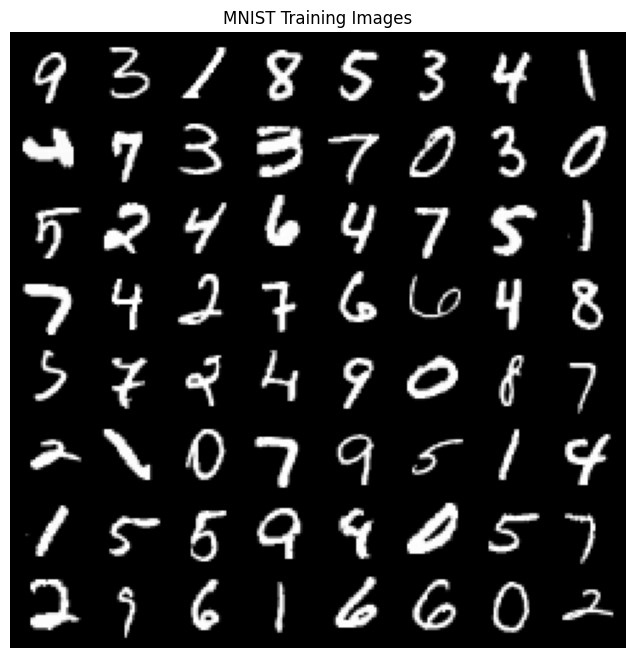


Training Basic GAN...

Epoch [1/10] D Loss: 0.3465 G Loss: 2.6518
Epoch [2/10] D Loss: 3.1943 G Loss: 0.2331
Epoch [3/10] D Loss: 1.0909 G Loss: 1.2252
Epoch [4/10] D Loss: 1.2812 G Loss: 1.0041
Epoch [5/10] D Loss: 1.9483 G Loss: 0.5883
Epoch [6/10] D Loss: 1.3567 G Loss: 0.9709
Epoch [7/10] D Loss: 0.9754 G Loss: 1.2997
Epoch [8/10] D Loss: 0.7901 G Loss: 1.5046
Epoch [9/10] D Loss: 1.8600 G Loss: 0.7483
Epoch [10/10] D Loss: 1.4173 G Loss: 1.0113

Generated Images from Basic GAN



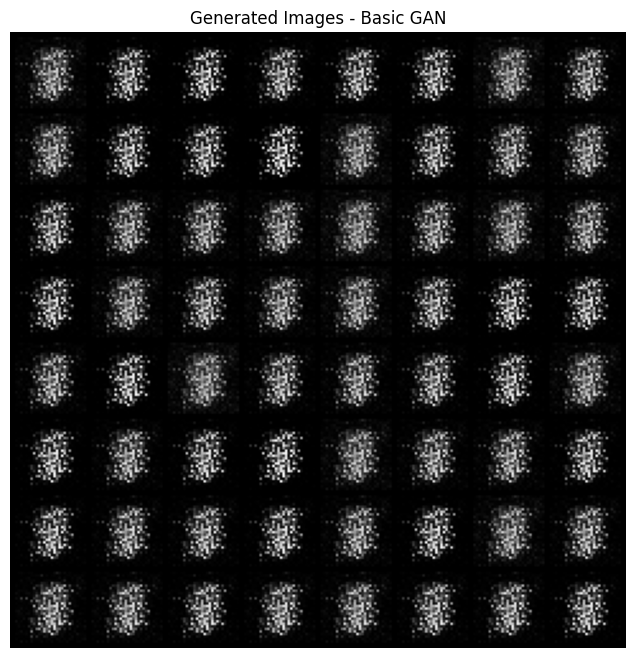


Training DCGAN...

Epoch [1/10] D Loss: 0.7253 G Loss: 1.4459
Epoch [2/10] D Loss: 0.6390 G Loss: 2.0401
Epoch [3/10] D Loss: 1.3857 G Loss: 0.5149
Epoch [4/10] D Loss: 0.8096 G Loss: 1.9044
Epoch [5/10] D Loss: 0.8044 G Loss: 1.0880
Epoch [6/10] D Loss: 0.7544 G Loss: 2.1300
Epoch [7/10] D Loss: 0.7120 G Loss: 1.5026
Epoch [8/10] D Loss: 0.6517 G Loss: 1.6138
Epoch [9/10] D Loss: 0.7352 G Loss: 0.8305
Epoch [10/10] D Loss: 0.5469 G Loss: 1.6337

Generated Images from DCGAN



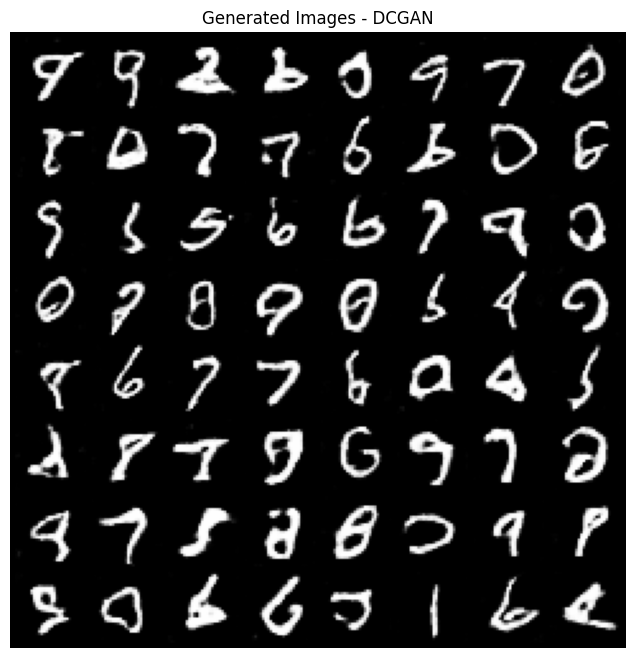

In [1]:
# ============================================================
# PYTORCH GAN + DCGAN (Convolutional GAN)
# Google Colab Ready
# ============================================================

# This notebook includes:
# 1. Basic GAN using Fully Connected Layers
# 2. DCGAN using Convolutional Layers
# 3. Adjustable epochs/layers
# 4. Image generation and visualization

# Dataset:
# MNIST Handwritten Digits

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

batch_size = 128

learning_rate = 0.0002

latent_dim = 100

epochs = 10

image_size = 28 * 28

# ============================================================
# LOAD MNIST DATASET
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# ============================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================

real_images, _ = next(iter(dataloader))

plt.figure(figsize=(8,8))

grid = make_grid(
    real_images[:64],
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("MNIST Training Images")

plt.axis("off")

plt.show()

# ============================================================
# BASIC GAN
# FULLY CONNECTED GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, 128),
            nn.ReLU(True),

            nn.Linear(128, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, image_size),

            nn.Tanh()
        )

    def forward(self, x):

        return self.model(x)

# ============================================================
# BASIC GAN
# FULLY CONNECTED DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(image_size, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)

# ============================================================
# INITIALIZE MODELS
# ============================================================

generator = Generator().to(device)

discriminator = Discriminator().to(device)

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.BCELoss()

# ============================================================
# OPTIMIZERS
# ============================================================

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=learning_rate
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate
)

# ============================================================
# TRAIN BASIC GAN
# ============================================================

print("\nTraining Basic GAN...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        # Flatten images
        real_images = real_images.view(
            batch_size_current,
            -1
        ).to(device)

        # Labels
        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES FROM BASIC GAN
# ============================================================

print("\nGenerated Images from Basic GAN\n")

noise = torch.randn(64, latent_dim).to(device)

generated_images = generator(noise)

generated_images = generated_images.view(
    -1,
    1,
    28,
    28
)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - Basic GAN")

plt.axis("off")

plt.show()

# ============================================================
# ============================================================
# DCGAN (CONVOLUTIONAL GAN)
# ============================================================
# ============================================================

# ============================================================
# CONVOLUTIONAL GENERATOR
# ============================================================

class DCGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                latent_dim,
                256,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, x):

        return self.model(x)

# ============================================================
# CONVOLUTIONAL DISCRIMINATOR
# ============================================================

class DCDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(0.2),

            nn.Flatten(),

            nn.Linear(128 * 7 * 7, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)

# ============================================================
# INITIALIZE DCGAN
# ============================================================

dc_generator = DCGenerator().to(device)

dc_discriminator = DCDiscriminator().to(device)

# ============================================================
# OPTIMIZERS
# ============================================================

g_optimizer = optim.Adam(
    dc_generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

d_optimizer = optim.Adam(
    dc_discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

# ============================================================
# TRAIN DCGAN
# ============================================================

print("\nTraining DCGAN...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = dc_discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES USING DCGAN
# ============================================================

print("\nGenerated Images from DCGAN\n")

noise = torch.randn(
    64,
    latent_dim,
    1,
    1
).to(device)

generated_images = dc_generator(noise)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - DCGAN")

plt.axis("off")

plt.show()

# ============================================================
# NOTES
# ============================================================

# You can experiment with:
# - epochs
# - batch_size
# - latent_dim
# - number of layers
# - convolution filters
# - learning rate

# DCGAN replaces fully connected layers with:
# - Conv2D
# - ConvTranspose2D

# This improves image generation quality significantly.

# **Testing with a Larger Hyperparameter**
**0.02 vs 0.0002**

In [7]:
batch_size = 128
learning_rate = 0.02
latent_dim = 100
epochs = 20
# image_size is derived from the dataset (28 * 28 for MNIST)
image_size = 28 * 28

print(f"Current Hyperparameters:\nBatch Size: {batch_size}\nLearning Rate: {learning_rate}\nLatent Dimension: {latent_dim}\nEpochs: {epochs}")

Current Hyperparameters:
Batch Size: 128
Learning Rate: 0.02
Latent Dimension: 100
Epochs: 20



Training Basic GAN with new hyperparameters...

Epoch [1/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [2/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [3/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [4/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [5/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [6/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [7/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [8/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [9/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [10/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [11/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [12/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [13/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [14/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [15/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [16/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [17/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [18/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [19/20] D Loss: 100.0000 G Loss: 0.0000
Epoch [20/20] D Loss: 100.0000 G Loss: 0.0000

Generated Images from Basic GAN



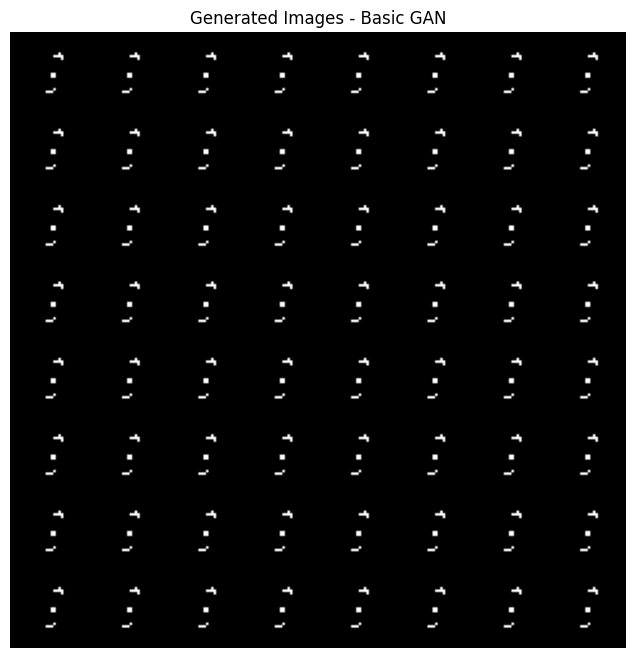


Training DCGAN with new hyperparameters...

Epoch [1/20] D Loss: 0.0000 G Loss: 21.4054
Epoch [2/20] D Loss: 0.0000 G Loss: 21.4645
Epoch [3/20] D Loss: 0.0000 G Loss: 21.5495
Epoch [4/20] D Loss: 0.0000 G Loss: 21.6564
Epoch [5/20] D Loss: 0.0000 G Loss: 21.7827
Epoch [6/20] D Loss: 0.0000 G Loss: 21.9268
Epoch [7/20] D Loss: 0.0000 G Loss: 22.0870
Epoch [8/20] D Loss: 0.0000 G Loss: 22.2608
Epoch [9/20] D Loss: 0.0000 G Loss: 22.4459
Epoch [10/20] D Loss: 0.0000 G Loss: 22.6399
Epoch [11/20] D Loss: 0.0000 G Loss: 22.8417
Epoch [12/20] D Loss: 0.0000 G Loss: 23.0500
Epoch [13/20] D Loss: 0.0000 G Loss: 23.2633
Epoch [14/20] D Loss: 0.0000 G Loss: 23.4838
Epoch [15/20] D Loss: 0.0000 G Loss: 23.7081
Epoch [16/20] D Loss: 0.0000 G Loss: 23.9345
Epoch [17/20] D Loss: 0.0000 G Loss: 24.1624
Epoch [18/20] D Loss: 0.0000 G Loss: 24.3914
Epoch [19/20] D Loss: 0.0000 G Loss: 24.6212
Epoch [20/20] D Loss: 0.0000 G Loss: 24.8531

Generated Images from DCGAN



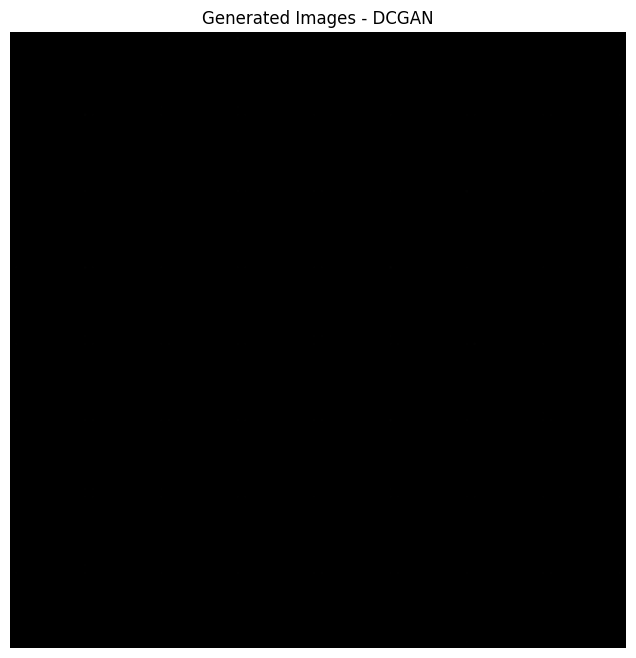

In [8]:
# ============================================================
# RE-INITIALIZE MODELS AND OPTIMIZERS WITH NEW HYPERPARAMETERS
# ============================================================

# Basic GAN Models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Basic GAN Optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(
    generator.parameters(),
    lr=learning_rate
)
d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate
)

# DCGAN Models
dc_generator = DCGenerator().to(device)
dc_discriminator = DCDiscriminator().to(device)

# DCGAN Optimizers (Note: DCGAN optimizers often use different beta values)
g_optimizer_dcgan = optim.Adam(
    dc_generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)
d_optimizer_dcgan = optim.Adam(
    dc_discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

# ============================================================
# TRAIN BASIC GAN
# ============================================================

print("\nTraining Basic GAN with new hyperparameters...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        # Flatten images
        real_images = real_images.view(
            batch_size_current,
            -1
        ).to(device)

        # Labels
        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES FROM BASIC GAN
# ============================================================

print("\nGenerated Images from Basic GAN\n")

noise = torch.randn(64, latent_dim).to(device)

generated_images = generator(noise)

generated_images = generated_images.view(
    -1,
    1,
    28,
    28
)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - Basic GAN")

plt.axis("off")

plt.show()

# ============================================================
# TRAIN DCGAN
# ============================================================

print("\nTraining DCGAN with new hyperparameters...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = dc_discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer_dcgan.zero_grad()

        d_loss.backward()

        d_optimizer_dcgan.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer_dcgan.zero_grad()

        g_loss.backward()

        g_optimizer_dcgan.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES USING DCGAN
# ============================================================

print("\nGenerated Images from DCGAN\n")

noise = torch.randn(
    64,
    latent_dim,
    1,
    1
).to(device)

generated_images = dc_generator(noise)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - DCGAN")

plt.axis("off")

plt.show()

# **Discussion of Effect of Learning Rate**

THe learning rate (0.02) is too high which leads to the discriminator to learning very quickly. Thus, the generator cannot learn hence why the BAsic GAN's Generator has a loss of 0.000 throughout

# **Testing with a Smaller Learning Rate and smaller Batch Size**

In [9]:
batch_size = 64
learning_rate = 0.00003
latent_dim = 100
epochs = 20
# image_size is derived from the dataset (28 * 28 for MNIST)
image_size = 28 * 28

print(f"Current Hyperparameters:\nBatch Size: {batch_size}\nLearning Rate: {learning_rate}\nLatent Dimension: {latent_dim}\nEpochs: {epochs}")

Current Hyperparameters:
Batch Size: 64
Learning Rate: 3e-05
Latent Dimension: 100
Epochs: 20



Training Basic GAN with new hyperparameters...

Epoch [1/20] D Loss: 0.7403 G Loss: 1.0419
Epoch [2/20] D Loss: 1.1560 G Loss: 0.7661
Epoch [3/20] D Loss: 1.1650 G Loss: 0.7655
Epoch [4/20] D Loss: 1.0007 G Loss: 0.9404
Epoch [5/20] D Loss: 0.9584 G Loss: 0.9586
Epoch [6/20] D Loss: 0.9568 G Loss: 1.0818
Epoch [7/20] D Loss: 0.7837 G Loss: 1.2359
Epoch [8/20] D Loss: 0.5914 G Loss: 1.4873
Epoch [9/20] D Loss: 0.8145 G Loss: 1.3573
Epoch [10/20] D Loss: 0.3616 G Loss: 2.1568
Epoch [11/20] D Loss: 0.3378 G Loss: 2.4121
Epoch [12/20] D Loss: 0.3896 G Loss: 2.0920
Epoch [13/20] D Loss: 0.2127 G Loss: 2.6262
Epoch [14/20] D Loss: 0.4133 G Loss: 2.2354
Epoch [15/20] D Loss: 0.2126 G Loss: 2.8207
Epoch [16/20] D Loss: 0.2657 G Loss: 2.9210
Epoch [17/20] D Loss: 0.2825 G Loss: 2.8913
Epoch [18/20] D Loss: 0.2396 G Loss: 3.2004
Epoch [19/20] D Loss: 0.3099 G Loss: 2.8495
Epoch [20/20] D Loss: 0.2424 G Loss: 3.6918

Generated Images from Basic GAN



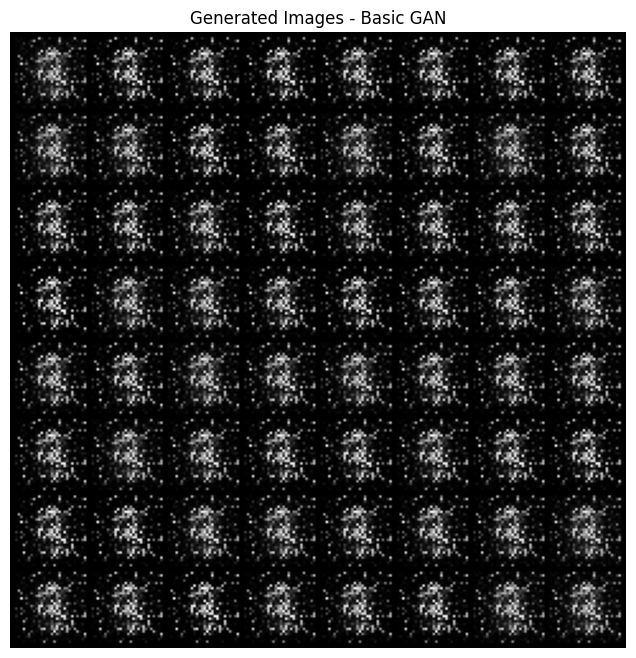


Training DCGAN with new hyperparameters...

Epoch [1/20] D Loss: 1.0328 G Loss: 0.9144
Epoch [2/20] D Loss: 0.6617 G Loss: 1.4146
Epoch [3/20] D Loss: 0.4819 G Loss: 1.6465
Epoch [4/20] D Loss: 0.4693 G Loss: 1.9611
Epoch [5/20] D Loss: 0.5461 G Loss: 1.4422
Epoch [6/20] D Loss: 0.6106 G Loss: 1.3933
Epoch [7/20] D Loss: 0.5953 G Loss: 1.8343
Epoch [8/20] D Loss: 0.5899 G Loss: 1.9315
Epoch [9/20] D Loss: 0.5736 G Loss: 1.7276
Epoch [10/20] D Loss: 0.5698 G Loss: 1.5040
Epoch [11/20] D Loss: 0.5788 G Loss: 1.7347
Epoch [12/20] D Loss: 0.6341 G Loss: 1.7054
Epoch [13/20] D Loss: 0.5253 G Loss: 1.1454
Epoch [14/20] D Loss: 0.6970 G Loss: 1.6594
Epoch [15/20] D Loss: 0.6349 G Loss: 1.8964
Epoch [16/20] D Loss: 0.6320 G Loss: 1.4667
Epoch [17/20] D Loss: 0.7710 G Loss: 2.2372
Epoch [18/20] D Loss: 0.6576 G Loss: 1.2834
Epoch [19/20] D Loss: 0.6585 G Loss: 1.7221
Epoch [20/20] D Loss: 0.6474 G Loss: 1.4438

Generated Images from DCGAN



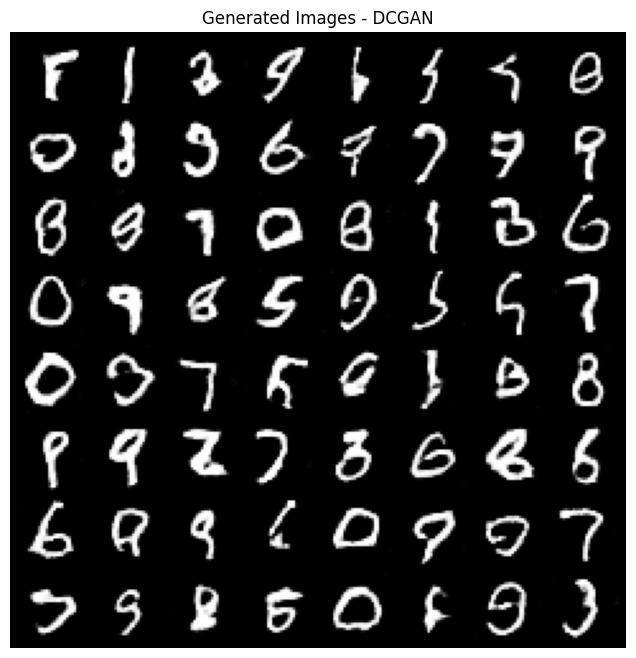

In [10]:
# ============================================================
# RE-INITIALIZE MODELS AND OPTIMIZERS WITH NEW HYPERPARAMETERS
# ============================================================

# Basic GAN Models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Basic GAN Optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(
    generator.parameters(),
    lr=learning_rate
)
d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate
)

# DCGAN Models
dc_generator = DCGenerator().to(device)
dc_discriminator = DCDiscriminator().to(device)

# DCGAN Optimizers (Note: DCGAN optimizers often use different beta values)
g_optimizer_dcgan = optim.Adam(
    dc_generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)
d_optimizer_dcgan = optim.Adam(
    dc_discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

# ============================================================
# TRAIN BASIC GAN
# ============================================================

print("\nTraining Basic GAN with new hyperparameters...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        # Flatten images
        real_images = real_images.view(
            batch_size_current,
            -1
        ).to(device)

        # Labels
        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim
        ).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES FROM BASIC GAN
# ============================================================

print("\nGenerated Images from Basic GAN\n")

noise = torch.randn(64, latent_dim).to(device)

generated_images = generator(noise)

generated_images = generated_images.view(
    -1,
    1,
    28,
    28
)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - Basic GAN")

plt.axis("off")

plt.show()

# ============================================================
# TRAIN DCGAN
# ============================================================

print("\nTraining DCGAN with new hyperparameters...\n")

for epoch in range(epochs):

    for i, (real_images, _) in enumerate(dataloader):

        batch_size_current = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = torch.ones(
            batch_size_current,
            1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size_current,
            1
        ).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        outputs = dc_discriminator(real_images)

        d_loss_real = criterion(
            outputs,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(
            fake_images.detach()
        )

        d_loss_fake = criterion(
            outputs,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer_dcgan.zero_grad()

        d_loss.backward()

        d_optimizer_dcgan.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1
        ).to(device)

        fake_images = dc_generator(noise)

        outputs = dc_discriminator(fake_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_optimizer_dcgan.zero_grad()

        g_loss.backward()

        g_optimizer_dcgan.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ============================================================
# GENERATE IMAGES USING DCGAN
# ============================================================

print("\nGenerated Images from DCGAN\n")

noise = torch.randn(
    64,
    latent_dim,
    1,
    1
).to(device)

generated_images = dc_generator(noise)

plt.figure(figsize=(8,8))

grid = make_grid(
    generated_images.cpu(),
    normalize=True
)

plt.imshow(
    grid.permute(1,2,0)
)

plt.title("Generated Images - DCGAN")

plt.axis("off")

plt.show()

# **Discussion**

Reducing the learning rate to 0.00003 improved learning compared to when it was 0.02. As always the BASIC GAN, struggles to create something legible. Though DGAN was able to create numbers that were legible.
A learning rate of 0.0002 is better than the one used in this experiments because the results of that were better and more crisp than the DGAN trained in this experiments. IT could be because it is too small of a value and there aren't enough epochs for it to allow the model to converge.

Also a smaller batch size was used in these experiments. It may have made training time faster, though quality of images is still poor. It must be clarified that learning rate more of an effect on the quality than batch size.